# **_INSTALL DEPENDENCIES_**

In [36]:
import os
import os.path as op
import requests
from urllib.request import urlretrieve
from IPython.display import Markdown, display


def create_folder(folder):
    if not op.exists(folder):
        os.mkdir(folder)
        print(f"Creating:\t\t {folder}")
    else:
        print(f"Already exist:\t\t {folder}")

def download_file(url, filename):
    if not op.exists(filename):
        print(f"Downloading:\t\t {url} --> {filename}")
        urlretrieve(url, filename)
    else:
        print(f"Already downloaded:\t {url} --> {filename}")


url = "https://raw.githubusercontent.com/KeremDUZENLI/python-keras-deep-learning/main/README.md"
FILES = "Files"
EX2DATA1_URL = "https://raw.githubusercontent.com/KeremDUZENLI/python-jupyter-machine-learning/refs/heads/main/notebooks/Files/ex2data1.txt"
EX2DATA1 = FILES + "/ex2data1.txt"
EX2DATA2_URL = "https://raw.githubusercontent.com/KeremDUZENLI/python-jupyter-machine-learning/refs/heads/main/notebooks/Files/ex2data2.txt"
EX2DATA2 = FILES + "/ex2data2.txt"

create_folder(FILES)
download_file(EX2DATA1_URL, EX2DATA1)
download_file(EX2DATA2_URL, EX2DATA2)

Already exist:		 Files
Already downloaded:	 https://raw.githubusercontent.com/KeremDUZENLI/python-jupyter-machine-learning/refs/heads/main/notebooks/Files/ex2data1.txt --> Files/ex2data1.txt
Already downloaded:	 https://raw.githubusercontent.com/KeremDUZENLI/python-jupyter-machine-learning/refs/heads/main/notebooks/Files/ex2data2.txt --> Files/ex2data2.txt


# Step 1: Import Libraries

In [37]:
import numpy as np
from numpy import concatenate, ones, array, shape, zeros, mean
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Step 2: Load Data

In [38]:
data1 = np.loadtxt(EX2DATA1, delimiter=",")
X1 = data1[:, 0:2]
y1 = data1[:, 2]

# Plotting
print("Number of examples for each class:")
# TODO
print("Class 0: ", np.sum(y1 == 0))
print("Class 1: ", np.sum(y1 == 1))

Number of examples for each class:
Class 0:  40
Class 1:  60


In [39]:
def plotData(X, y):
    plt.plot(X[y == 1, 0], X[y == 1, 1], "r*")
    plt.legend(["Admitted", "Not admitted"])
    #plt.show()

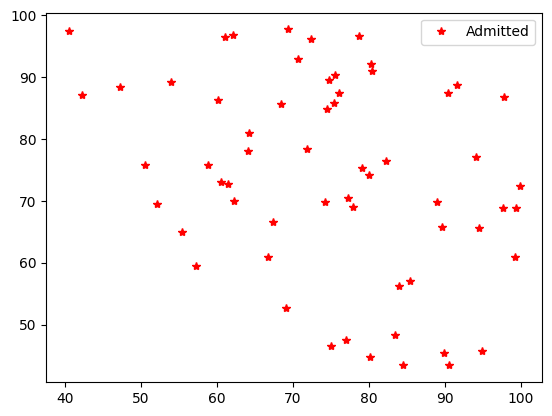

In [40]:
plotData(X1, y1)

# Step 3: Sigmoid

In [41]:
def sigmoid(z):
    return 1 / (1+np.exp(-z))

In [42]:
z = np.array([0, 2, -2])
sigmoid(z)

array([0.5       , 0.88079708, 0.11920292])

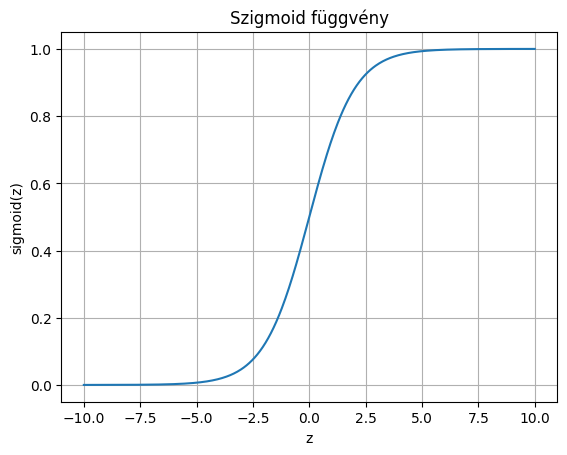

In [43]:
z_values = np.linspace(-10, 10, 500)
sigmoid_values = sigmoid(z_values)

plt.plot(z_values, sigmoid_values)
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.title("Szigmoid függvény")
plt.grid(True)
#plt.show()

# Step 4: Compute Cost and Gradient

In [44]:
def costFunction(theta, X, y):
    m = y.size
    pred = sigmoid(X.dot(theta))
    J = (-1/m) * (y.T.dot(np.log(pred)) + (1-y).T.dot(np.log(1-pred)))
    grad = (1 / m) * X.T.dot(pred - y)
    
    return J, grad

In [45]:
# Add intercept term
m, n = shape(X1)
X1_aug = concatenate((ones((m,1)), X1), axis=1)

# Initialize parameters
theta_init = zeros(n+1)

# Compute cost and gradient at theta_init
J, grad = costFunction(theta_init, X1_aug, y1)
print("Cost at initial theta:", J)
print("Gradient at initial theta:", grad)

# Test with non-zero theta
theta_test = array([0, 0, 0])
J_test, grad_test = costFunction(theta_test, X1_aug, y1)
print("Cost at test theta:", J_test)
print("Gradient at test theta:", grad_test)

Cost at initial theta: 0.6931471805599452
Gradient at initial theta: [ -0.1        -12.00921659 -11.26284221]
Cost at test theta: 0.6931471805599452
Gradient at test theta: [ -0.1        -12.00921659 -11.26284221]


# Step 5: Optimize Parameters

In [46]:
options = {"maxiter": 400}
result = minimize(fun=costFunction, x0=theta_init, args=(X1_aug, y1),
                  jac=True, method="TNC", options=options)
theta_opt = result.x
cost_opt = result.fun

print("Optimized theta:", theta_opt)
print("Optimized cost:", cost_opt)

Optimized theta: [-25.16131857   0.20623159   0.20147149]
Optimized cost: 0.20349770158947486


C:\Users\benja\AppData\Local\Temp\ipykernel_26844\4125695667.py:2: OptimizeWarning: Unknown solver options: maxiter
  result = minimize(fun=costFunction, x0=theta_init, args=(X1_aug, y1),


In [47]:
def plotDecisionBoundary(theta, X, y):
    plotData(X[:,1:3], y)

    if X.shape[1] <= 3:
        # Linear decision boundary
        plot_x = np.array([min(X[:,1])-2, max(X[:,1])+2])
        plot_y = (-1/theta[2])*(theta[1]*plot_x + theta[0])
        plt.plot(plot_x, plot_y)
    else:
        pass

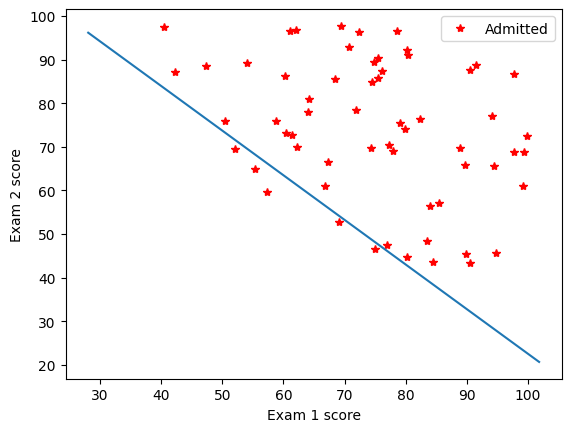

In [48]:
plotDecisionBoundary(theta_opt, X1_aug, y1)
plt.xlabel("Exam 1 score")
plt.ylabel("Exam 2 score")
plt.show()

# Step 6: Make Predictions

In [57]:
def predict(theta, X):
    pred = sigmoid(X.dot(theta))
    label = (pred >= 0.5).astype(int)
    return label

In [58]:
# Example: student with scores 45 and 85
prob = sigmoid(array([1, 45, 85]) @ theta_opt)
print(f"Admission probability for (45,85): {prob:.3f}")

# Training set accuracy
p_train = predict(theta_opt, X1_aug)
accuracy = mean(p_train == y1) * 100
print(f"Training accuracy: {accuracy:.1f}%")

Admission probability for (45,85): 0.776
Training accuracy: 89.0%


# Step 7: Regularized Logistic Regression

In [71]:
def costFunctionReg(theta, X, y, _lambda):
    m = y.size
    # TODO
    pred = sigmoid(X.dot(theta))
    eps = 1e-15
    pred = np.clip(pred, eps, 1 - eps)
    J = (-1/m) * (y.T.dot(np.log(pred)) + (1-y).T.dot(np.log(1-pred)))
    J += (_lambda / (2*m)) * np.sum(theta[1:] ** 2)
    grad = (1 / m) * X.T.dot(pred - y)
    grad[1:] += (_lambda / m) * theta[1:]

    return J, grad

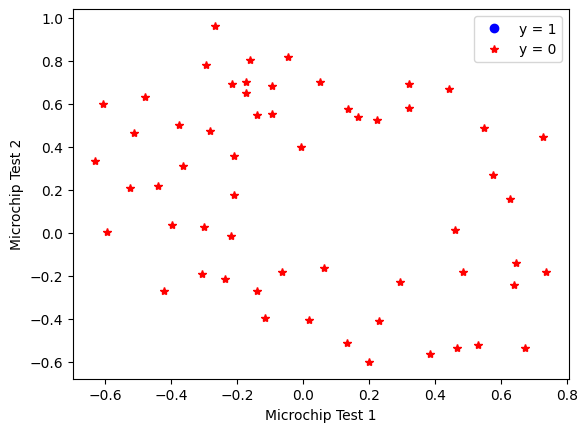

In [72]:
data2 = np.loadtxt(EX2DATA2, delimiter=",")
X2 = data2[:, 0:2]
y2 = data2[:, 2]

plotData(X2, y2)
plt.xlabel("Microchip Test 1")
plt.ylabel("Microchip Test 2")
plt.plot([], [], "bo", label="y = 1")
plt.plot([], [], "r*", label="y = 0")
plt.legend()
plt.show()


In [65]:
def mapFeature(X1, X2, degree=6):
    out = np.ones((X1.shape[0], 1))
    for i in range(1, degree+1):
        for j in range(i+1):
            out = np.hstack((out, (X1**(i-j) * X2**j).reshape(-1,1)))
    return out

In [73]:
# Add polynomial features
X2_poly = mapFeature(X2[:, 0], X2[:, 1])

# Initialize parameters and lambda
theta_init2 = zeros(X2_poly.shape[1])
_lambda = 1

# Compute initial cost and gradient
J_reg, grad_reg = costFunctionReg(theta_init2, X2_poly, y2, _lambda)
print("Initial cost (reg):", J_reg)
print("Initial gradient (first 5 values):", grad_reg[:5])

Initial cost (reg): 0.6931471805599454
Initial gradient (first 5 values): [8.47457627e-03 1.87880932e-02 7.77711864e-05 5.03446395e-02
 1.15013308e-02]


# Step 8: Optimize Regularized Logistic Regression

In [74]:
def plotDecisionBoundary(theta, X, y):
    plotData(X[:,1:3], y)

    if X.shape[1] <= 3:
        # Linear decision boundary
        plot_x = np.array([min(X[:,1])-2, max(X[:,1])+2])
        plot_y = (-1/theta[2])*(theta[1]*plot_x + theta[0])
        plt.plot(plot_x, plot_y)
    else:
        # Non-linear boundary (polynomial features)
        u = np.linspace(-1, 1.5, 50)
        v = np.linspace(-1, 1.5, 50)
        z = np.zeros((len(u), len(v)))
        for i in range(len(u)):
            for j in range(len(v)):
                z[i,j] = mapFeature(np.array([u[i]]), np.array([v[j]])) @ theta
        z = z.T
        plt.contour(u, v, z, levels=[0], colors='c', linewidths=2)

C:\Users\benja\AppData\Local\Temp\ipykernel_26844\2907207058.py:2: OptimizeWarning: Unknown solver options: maxiter
  result_reg = minimize(fun=costFunctionReg, x0=theta_init2, args=(X2_poly, y2, _lambda),
C:\Users\benja\AppData\Local\Temp\ipykernel_26844\23154304.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  z[i,j] = mapFeature(np.array([u[i]]), np.array([v[j]])) @ theta


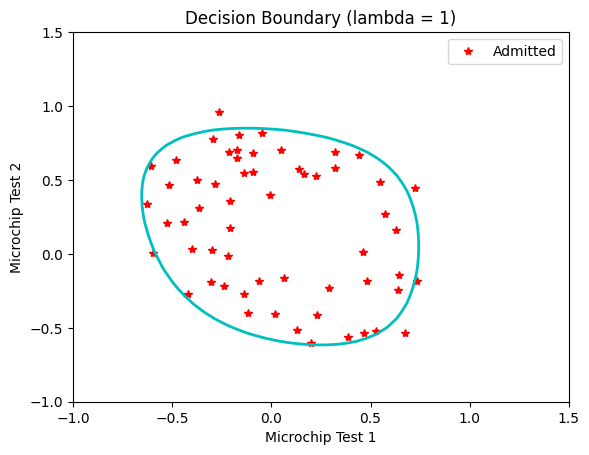

Training accuracy (reg): 83.05%


In [75]:
options = {"maxiter": 1800}
result_reg = minimize(fun=costFunctionReg, x0=theta_init2, args=(X2_poly, y2, _lambda),
                      jac=True, method="TNC", options=options)
theta_reg = result_reg.x

# Plot decision boundary
plotDecisionBoundary(theta_reg, X2_poly, y2)
plt.title(f"Decision Boundary (lambda = {_lambda})")
plt.xlabel("Microchip Test 1")
plt.ylabel("Microchip Test 2")
plt.show()

# Training set accuracy
p_train2 = predict(theta_reg, X2_poly)
accuracy2 = mean(p_train2 == y2) * 100
print(f"Training accuracy (reg): {accuracy2:.2f}%")